# Analyse de base de données environnementale et de confort thermique prenant en compte la vitesse d’air et les conditions chaude et humide.
## ETAPE 0

In [1]:
import pandas as pd

URL_META = "https://github.com/CenterForTheBuiltEnvironment/ashrae-db-II/raw/master/v2.1.0/db_metadata.csv"
URL_MEAS = "https://github.com/CenterForTheBuiltEnvironment/ashrae-db-II/raw/master/v2.1.0/db_measurements_v2.1.0.csv.gz"

meta = pd.read_csv(URL_META)
meas = pd.read_csv(URL_MEAS)
# on regarde le contenu des deux bases
print("metadata :", meta.shape)
print("measurements :", meas.shape)

df = meas.merge(
    meta,
    on="building_id",
    how="left",
    validate="many_to_one",
    suffixes=("", "_meta")
)
print("base fusionnée :", df.shape)

metadata : (809, 23)
measurements : (109033, 53)
base fusionnée : (109033, 75)


C:\Users\yanis\AppData\Local\Temp\ipykernel_7248\1423825777.py:7: DtypeWarning: Columns (5,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  meas = pd.read_csv(URL_MEAS)


In [2]:
print(df.shape)
print('---------------')
print(df.info)
print('---------------')
print(df.columns)
print('---------------')
df.to_csv('maBaseDeTravailDuPFE.csv', index=False)

(109033, 75)
---------------
<bound method DataFrame.info of          index  record_id  building_id             timestamp   season  \
0            0          1            1  1995-05-18T00:00:00Z   winter   
1            1          2            1  1995-05-18T00:00:00Z   winter   
2            2          3            1  1995-05-18T00:00:00Z   winter   
3            3          4            1  1995-05-18T00:00:00Z   winter   
4            4          5            1  1995-05-18T00:00:00Z   winter   
...        ...        ...          ...                   ...      ...   
109028  110065     110066          809  2014-06-02T00:00:00Z  hot/wet   
109029  110066     110067          809  2014-06-02T00:00:00Z  hot/wet   
109030  110067     110068          809  2014-06-02T00:00:00Z  hot/wet   
109031  110068     110069          809  2014-06-02T00:00:00Z  hot/wet   
109032  110069     110070          809  2014-06-02T00:00:00Z  hot/wet   

       subject_id  age  gender  ht  wt  ...  records  has_age 

In [3]:
for col in df.select_dtypes(include=["object", "string"]):
    print(f"{col} ({df[col].nunique()} valeurs) :")
    print(df[col].unique())
    print()

timestamp (2836 valeurs) :
['1995-05-18T00:00:00Z' '1995-05-19T00:00:00Z' '1995-05-22T00:00:00Z' ...
 '2014-05-04T00:00:00Z' '2014-06-01T00:00:00Z' '2014-06-02T00:00:00Z']

season (6 valeurs) :
['winter' 'summer' 'cool/dry' 'hot/wet' 'spring' 'autumn' nan]

subject_id (2651 valeurs) :
[10.0 14.0 15.0 ... '703' '701' '815']

gender (3 valeurs) :
['female' 'male' nan 'undefined']

thermal_acceptability (2 valeurs) :
['acceptable' 'unacceptable' nan]

thermal_preference (3 valeurs) :
['cooler' 'no change' 'warmer' nan]

air_movement_acceptability (2 valeurs) :
['unacceptable' 'acceptable' nan]

air_movement_preference (3 valeurs) :
['more' 'no change' nan 'less']

building_id_inf (2 valeurs) :
['no' 'yes']

contributor (55 valeurs) :
['David Rowe' 'Fred Baumann' 'Gail Brager' 'Jill Brown' 'Richard de Dear'
 'Giovanna Donnini' 'John Busch' 'Nick Baker' 'Tri Karyono' 'Alison Kwok'
 'Jeetika Malik' 'Guy Newsham' 'Fergus Nicol' 'Nigel Oseland'
 'Salvatore Carlucci' 'Elisabetta Maria Patane' '

## Etape 1 exploration de la base
## Question 1 :

In [4]:
# A partir de "parameter_description" et de la liste des climats dispo (31)
CLIMATE_MAP = {
    "tropical wet savanna": ("Aw", "A", True),
    "tropical savanna": ("Aw", "A", True),
    "tropical monsoon": ("Am", "A", True),
    "tropical": ("A", "A", True),
    "wet equatorial": ("Af", "A", True),
    "tropical rainforest": ("Af", "A", True),
    "tropical dry savanna": ("As", "A", True),
}

df["koppen_code"] = df["climate"].map(
    lambda x: CLIMATE_MAP.get(x, (None, None, None))[0]
)

df["koppen_group"] = df["climate"].map(
    lambda x: CLIMATE_MAP.get(x, (None, None, None))[1]
)

df["is_tropical"] = df["climate"].map(
    lambda x: CLIMATE_MAP.get(x, (None, None, None))[2]
)

trop = df[df["is_tropical"] == True].copy()

print("Nombre total d'observations :", len(df))
print("Nombre d'observations tropicales :", len(trop))
print("Nombre de bâtiments tropicaux :", trop["building_id"].nunique())

Nombre total d'observations : 109033
Nombre d'observations tropicales : 21974
Nombre de bâtiments tropicaux : 253


In [5]:
print("Répartition des climats tropicaux :")
print(trop["climate"].value_counts())

print("\nRépartition par type de refroidissement :")
print(trop["cooling_type"].value_counts())

print("\nRépartition par type de bâtiment :")
print(trop["building_type"].value_counts())

Répartition des climats tropicaux :
climate
tropical wet savanna    8383
tropical savanna        6980
tropical monsoon        2101
tropical                1594
wet equatorial          1414
tropical rainforest     1350
tropical dry savanna     152
Name: count, dtype: int64

Répartition par type de refroidissement :
cooling_type
naturally ventilated    8875
air conditioned         8654
mixed mode              4445
Name: count, dtype: int64

Répartition par type de bâtiment :
building_type
office                 15468
multifamily housing     4161
classroom               2245
others                   100
Name: count, dtype: int64


In [6]:
# Nombre total d'observations tropicales
n_total = len(trop)

# Palier 1 : Tdb + RH
P1 = trop["ta"].notna() & trop["rh"].notna()

# Palier 2 : Tdb + RH + Tg/Tr
P2 = P1 & (trop["tg"].notna() | trop["tr"].notna())

# Palier 3 : Tdb + RH + Tg/Tr + V
P3 = P2 & trop["vel"].notna()

# Palier 4 : Tdb + RH + Tg/Tr + V + clo
P4 = P3 & trop["clo"].notna()

# Palier 5 : Tdb + RH + Tg/Tr + V + clo + métabolisme et/ou activité/fonction du bâtiment
has_met = trop["met"].notna()

has_activity = trop[
    ["activity_10", "activity_20", "activity_30", "activity_60"]
].notna().any(axis=1)

has_building = trop["building_type"].notna()

P5 = P4 & (has_met | has_activity | has_building)

# Résultats
resultats_q1 = pd.DataFrame({
    "Palier": [
        "P1 : Tdb + RH",
        "P2 : Tdb + RH + Tg/Tr",
        "P3 : Tdb + RH + Tg/Tr + V",
        "P4 : Tdb + RH + Tg/Tr + V + clo",
        "P5 : Tdb + RH + Tg/Tr + V + clo + métabolisme et/ou activité/fonction du bâtiment"
    ],
    "Nombre d'observations": [
        P1.sum(),
        P2.sum(),
        P3.sum(),
        P4.sum(),
        P5.sum()
    ]
})

resultats_q1["Pourcentage"] = (
    resultats_q1["Nombre d'observations"] / n_total * 100
).round(1)

resultats_q1

,Palier,Nombre d'observations,Pourcentage
0,P1 : Tdb + RH,21914,99.7
1,P2 : Tdb + RH + Tg/Tr,14104,64.2
2,P3 : Tdb + RH + Tg/Tr + V,9964,45.3
3,P4 : Tdb + RH + Tg/Tr + V + clo,9730,44.3
4,P5 : Tdb + RH + Tg/Tr + V + clo + métabolisme ...,9730,44.3


In [7]:
print("Observations P4 :", P4.sum())
print("P4 + met :", (P4 & has_met).sum())
print("P4 + activité :", (P4 & has_activity).sum())
print("P4 + fonction/type bâtiment :", (P4 & has_building).sum())
print("P4 + met OU activité OU bâtiment :", P5.sum())

Observations P4 : 9730
P4 + met : 9730
P4 + activité : 3421
P4 + fonction/type bâtiment : 9730
P4 + met OU activité OU bâtiment : 9730


In [8]:
# Attribution du palier maximal atteint pour chaque observation

trop["tier"] = 0

trop.loc[P1, "tier"] = 1
trop.loc[P2, "tier"] = 2
trop.loc[P3, "tier"] = 3
trop.loc[P4, "tier"] = 4
trop.loc[P5, "tier"] = 5

In [9]:
# Une ligne par building_id tropical

study = (
    trop.groupby("building_id")
    .agg(
        publication=("publication", "first"),
        country=("country", "first"),
        city=("city", "first"),
        climate_label=("climate", "first"),
        koppen=("koppen_code", "first"),
        building_type=("building_type", "first"),
        cooling_type=("cooling_type", "first"),
        n_votes=("record_id", "count"),
        max_tier=("tier", "max"),
        met_source=("met_source", "first"),
    )
    .reset_index()
    .sort_values("n_votes", ascending=False)
)

study

,building_id,publication,country,city,climate_label,koppen,building_type,cooling_type,n_votes,max_tier,met_source
224,654,https://doi.org/10.1016/j.buildenv.2014.01.002,india,chennai,tropical wet savanna,Aw,office,mixed mode,1527,1,None
214,592,https://doi.org/10.1016/j.buildenv.2009.06.005,brazil,maceio,tropical monsoon,Am,classroom,naturally ventilated,1160,5,None
226,656,https://doi.org/10.1016/j.buildenv.2014.01.002,india,chennai,tropical wet savanna,Aw,office,mixed mode,1127,1,None
213,591,https://doi.org/10.1016/j.buildenv.2009.06.005,brazil,maceio,tropical monsoon,Am,classroom,naturally ventilated,914,5,None
244,735,https://doi.org/10.1016/j.buildenv.2016.09.024,malaysia,kuala lumpur,tropical,A,office,air conditioned,629,5,None
...,...,...,...,...,...,...,...,...,...,...,...
94,324,https://doi.org/10.1016/j.buildenv.2022.109187,india,bengaluru,tropical wet savanna,Aw,multifamily housing,mixed mode,1,5,original_data
95,325,https://doi.org/10.1016/j.buildenv.2022.109187,india,bengaluru,tropical wet savanna,Aw,multifamily housing,naturally ventilated,1,5,original_data
96,326,https://doi.org/10.1016/j.buildenv.2022.109187,india,bengaluru,tropical wet savanna,Aw,multifamily housing,mixed mode,1,5,original_data
97,327,https://doi.org/10.1016/j.buildenv.2022.109187,india,bengaluru,tropical wet savanna,Aw,multifamily housing,naturally ventilated,1,5,original_data


In [10]:
study.to_csv("tropical_studies_list.csv", index=False)

In [11]:
# Regroupement par publication
pub = (
    trop.groupby("publication", dropna=False)
    .agg(
        n_buildings=("building_id", "nunique"),
        countries=("country", lambda x: sorted(set(x.dropna()))),
        koppen=("koppen_code", lambda x: sorted(set(x.dropna()))),
        building_types=("building_type", lambda x: sorted(set(x.dropna()))),
        cooling_types=("cooling_type", lambda x: sorted(set(x.dropna()))),
        n_votes=("record_id", "count"),
        max_tier=("tier", "max"),
        min_tier=("tier", "min"),
        contributor=("contributor", lambda x: sorted(set(x.dropna())))
    )
    .reset_index()
    .sort_values("n_votes", ascending=False)
)

pub


,publication,n_buildings,countries,koppen,building_types,cooling_types,n_votes,max_tier,min_tier,contributor
2,"Kwok, A.G. (1998). Thermal Comfort in Tropical...",12,[usa],[Aw],[office],"[air conditioned, naturally ventilated]",3544,2,2,[Alison Kwok]
10,https://doi.org/10.1016/j.buildenv.2014.01.002,4,[india],[Aw],[office],"[air conditioned, mixed mode]",2907,1,1,[Indraganti Madhavi]
8,https://doi.org/10.1016/j.buildenv.2009.06.005,2,[brazil],[Am],[classroom],[naturally ventilated],2074,5,5,[Christhina Candido]
11,https://doi.org/10.1016/j.buildenv.2015.12.019,8,[india],[Aw],[office],"[air conditioned, naturally ventilated]",2029,1,1,[Sanyogita Manu]
12,https://doi.org/10.1016/j.buildenv.2016.09.024,8,"[indonesia, malaysia, singapore]",[A],[office],"[air conditioned, mixed mode, naturally ventil...",1594,5,3,[Siti Aisyah Damiati]
5,"de Dear, R.J. & Fountain, M.E. (1994). Field e...",23,[australia],[Aw],[office],[air conditioned],1231,5,5,[Richard de Dear]
7,https://doi.org/10.1016/0378-7788(92)90016-A,5,[thailand],[Aw],[office],"[air conditioned, naturally ventilated]",1160,5,3,[John Busch]
13,https://doi.org/10.1016/j.buildenv.2022.109187,140,[india],[Aw],[multifamily housing],"[mixed mode, naturally ventilated]",1070,5,5,[Rajan Rawal]
15,https://doi.org/10.1016/j.renene.2012.01.017,5,[mexico],"[As, Aw]",[multifamily housing],[mixed mode],1055,1,1,[Ramona Romero]
4,"de Dear, R. J. & Auliciems, A. (1985). Validat...",15,[australia],[Aw],[office],[air conditioned],1045,5,5,[Richard de Dear]


In [12]:
pub.to_csv("tropical_publications_list.csv", index=False)

In [13]:
# Verification : est-ce que toutes les études tropicales ont une publication renseignée ?
n_missing_pub = trop["publication"].isna().sum()
print("Votes tropicaux sans publication renseignée :", n_missing_pub)

missing_pub_buildings = (
    trop[trop["publication"].isna()]
    .groupby("building_id")
    .agg(
        country=("country", "first"),
        city=("city", "first"),
        climate=("climate", "first"),
        building_type=("building_type", "first"),
        cooling_type=("cooling_type", "first"),
        contributor=("contributor", "first"),
        n_votes=("record_id", "count"),
    )
)
missing_pub_buildings

Votes tropicaux sans publication renseignée : 100


,country,city,climate,building_type,cooling_type,contributor,n_votes
building_id,,,,,,,
808,malaysia,kota kinabalu,tropical rainforest,others,air conditioned,Harimi Djamila,12
809,malaysia,kota kinabalu,tropical rainforest,others,air conditioned,Harimi Djamila,88


## Question 2 :

In [14]:
# Defini tout ce qui n'est pas dans "is_tropical"
non_trop = df[df["is_tropical"] != True].copy()
climats_hors_tropical = (
    non_trop["climate"]
    .value_counts()
    .rename_axis("climate")
    .reset_index(name="n_observations")
)

climats_hors_tropical

,climate,n_observations
0,hot-summer mediterranean,21722
1,humid subtropical,15257
2,hot semi-arid,8642
3,warm-summer mediterranean,5773
4,mediterranean,4584
5,temperate oceanic,4422
6,monsoon-influenced hot-summer humid continental,3739
7,warm-summer humid continental,2990
8,hot desert,2083
9,desert (hot arid),2011


In [15]:
print("Votes hors tropical :", len(non_trop))
print("Bâtiments hors tropical :", non_trop["building_id"].nunique())

Votes hors tropical : 87059
Bâtiments hors tropical : 556


In [16]:
non_trop[["ta","rh","vel","clo"]].describe(percentiles=[.25,.5,.75]).round(2)

,ta,rh,vel,clo
count,87059.00,80320.00,75911.00,82070.00
mean,24.18,45.41,0.16,0.69
std,3.66,15.60,0.25,0.29
min,10.10,2.00,0.00,0.03
25%,22.12,33.20,0.04,0.50
50%,23.60,44.35,0.08,0.65
75%,26.00,56.00,0.17,0.79
max,39.80,100.00,3.97,4.00


In [17]:
# Sous-ensemble de référence : palier 4 uniquement (Tdb+RH+Tg/Tr+V+clo complets)
trop_complete = trop[P4].copy()
print("n observations :", len(trop_complete))
print("n bâtiments :", trop_complete["building_id"].nunique())

n observations : 9730
n bâtiments : 199


In [18]:
print("Climat :\n", trop_complete["climate"].value_counts())
print("\nPays (n =", trop_complete["country"].nunique(), ") :\n", trop_complete["country"].value_counts())
print("\nType de bâtiment :\n", trop_complete["building_type"].value_counts())
print("\nMode de refroidissement :\n", trop_complete["cooling_type"].value_counts())

Climat :
 climate
tropical savanna        3422
tropical monsoon        2101
tropical wet savanna    1799
tropical                1591
wet equatorial           817
Name: count, dtype: int64

Pays (n = 7 ) :
 country
australia    2276
brazil       2125
india        1775
thailand     1146
malaysia     1135
singapore     873
indonesia     400
Name: count, dtype: int64

Type de bâtiment :
 building_type
office                 5881
classroom              2074
multifamily housing    1775
Name: count, dtype: int64

Mode de refroidissement :
 cooling_type
air conditioned         4576
naturally ventilated    4459
mixed mode               695
Name: count, dtype: int64


In [19]:
trop_complete[["ta","rh","vel","clo"]].describe(percentiles=[.25,.5,.75]).round(2)

,ta,rh,vel,clo
count,9730.00,9730.00,9730.00,9730.00
mean,26.10,61.20,0.29,0.49
std,3.04,10.47,0.36,0.18
min,18.30,23.00,0.00,0.05
25%,23.70,55.10,0.10,0.38
50%,25.70,61.00,0.16,0.48
75%,28.68,67.51,0.31,0.57
max,34.20,99.70,3.62,2.34


In [20]:
def paliers_completude(sub):
    has_tdb = sub["ta"].notna()
    has_rh  = sub["rh"].notna()
    has_tgtr = sub["tg"].notna() | sub["tr"].notna()
    has_v   = sub["vel"].notna()
    has_clo = sub["clo"].notna()
    has_met = sub["met"].notna()
    has_activity = sub[
    ["activity_10", "activity_20", "activity_30", "activity_60"]
    ].notna().any(axis=1)
    has_building = sub["building_type"].notna()


    P1 = has_tdb & has_rh
    P2 = P1 & has_tgtr
    P3 = P2 & has_v
    P4 = P3 & has_clo
    P5 = P4 & (has_met | has_activity | has_building)

    n = len(sub)
    return pd.DataFrame({
        "Palier": ["P1: Tdb+RH", "P2: +Tg/Tr", "P3: +V", "P4: +clo", "P5: + met et/ou act/fonc bât"],
        "n_votes": [P1.sum(), P2.sum(), P3.sum(), P4.sum(), P5.sum()],
        "%": [round(100*P1.sum()/n,1), round(100*P2.sum()/n,1),
              round(100*P3.sum()/n,1), round(100*P4.sum()/n,1), round(100*P5.sum()/n,1)],
    })

## Critère A 

In [21]:
climats_proches_label = [
    "humid subtropical",                    # Cfa - "humid" dans la définition Köppen
    "monsoon-influenced humid subtropical",  # Cwa - idem
    "hot semi-arid",                         # BSh - cas limite
]
crit_A = non_trop["climate"].isin(climats_proches_label)
print("Critère A - n votes :", crit_A.sum())
non_trop.loc[crit_A, "climate"].value_counts()

Critère A - n votes : 25685


climate
humid subtropical                       15257
hot semi-arid                            8642
monsoon-influenced humid subtropical     1786
Name: count, dtype: int64

In [22]:
res_A = paliers_completude(non_trop[crit_A])
res_A

,Palier,n_votes,%
0,P1: Tdb+RH,25197,98.1
1,P2: +Tg/Tr,10034,39.1
2,P3: +V,9697,37.8
3,P4: +clo,9689,37.7
4,P5: + met et/ou act/fonc bât,9689,37.7


## Critère B

In [23]:
# Seuils derives du sous-ensemble de reference
SEUIL_TDB = round(trop_complete["ta"].median(), 1)
SEUIL_RH  = round(trop_complete["rh"].median(), 1)
print("Seuils :", SEUIL_TDB, SEUIL_RH)

crit_B = (non_trop["ta"] >= SEUIL_TDB) & (non_trop["rh"] >= SEUIL_RH)
print("Critere B - n votes :", crit_B.sum())
non_trop.loc[crit_B, "climate"].value_counts()

Seuils : 25.7 61.0
Critere B - n votes : 5640


climate
humid subtropical                                  2448
hot semi-arid                                      1360
desert (hot arid)                                   511
hot desert                                          322
monsoon-influenced humid subtropical                316
temperate                                           258
monsoon-influenced hot-summer humid continental     172
hot-summer mediterranean                            107
semi arid midlatitude                                81
subtropical hot and dry                              19
temperate oceanic                                    19
semi arid high altitude                              15
mediterranean                                         5
warm-summer mediterranean                             5
monsoon-influenced temperate oceanic                  2
Name: count, dtype: int64

In [24]:
res_B = paliers_completude(non_trop[crit_B])
res_B

,Palier,n_votes,%
0,P1: Tdb+RH,5640,100.0
1,P2: +Tg/Tr,3295,58.4
2,P3: +V,3111,55.2
3,P4: +clo,3097,54.9
4,P5: + met et/ou act/fonc bât,3097,54.9


## Comparaison A et B

In [25]:
comparaison = pd.DataFrame({
    "Critère": ["A (label climatique)", "B (seuil mesuré)"],
    "n_votes": [int(crit_A.sum()), int(crit_B.sum())],
    "% P4 atteint": [res_A.loc[3, "%"], res_B.loc[3, "%"]],
})
print(comparaison)

seulement_B = crit_B & ~crit_A
print("\nVotes communs aux deux critères :", (crit_A & crit_B).sum())
print("Votes trouvés par B mais PAS par A :", seulement_B.sum())

                Critère  n_votes  % P4 atteint
0  A (label climatique)    25685          37.7
1      B (seuil mesuré)     5640          54.9

Votes communs aux deux critères : 4124
Votes trouvés par B mais PAS par A : 1516


In [26]:
cas_inattendus = non_trop[
    seulement_B & non_trop["climate"].isin(["hot desert", "desert (hot arid)"])
]
print("Votes désert qui remplissent quand même le seuil chaud-humide :", len(cas_inattendus))
cas_inattendus[["building_id","country","city","cooling_type","ta","rh"]].drop_duplicates("building_id")

Votes désert qui remplissent quand même le seuil chaud-humide : 833


,building_id,country,city,cooling_type,ta,rh
18130,172,pakistan,karachi,naturally ventilated,31.1,75.9
18559,173,pakistan,karachi,naturally ventilated,26.9,64.0
18790,174,pakistan,multan,naturally ventilated,29.6,77.0
20607,177,pakistan,quettar,naturally ventilated,39.4,62.3
51121,568,tunisia,gabes,naturally ventilated,26.3,62.0
51240,570,tunisia,gabes,naturally ventilated,30.8,63.0
107858,806,iran,bandar abbas,naturally ventilated,29.6,63.0


In [27]:
for bid in [172, 173, 174, 177, 568, 570, 806]:
    b = df[df["building_id"] == bid]
    print(f"building_id {bid} : n={len(b)}, RH médiane={b['rh'].median():.1f}, RH 75e percentile={b['rh'].quantile(.75):.1f}")

building_id 172 : n=190, RH médiane=66.5, RH 75e percentile=69.9
building_id 173 : n=470, RH médiane=43.7, RH 75e percentile=59.4
building_id 174 : n=436, RH médiane=69.0, RH 75e percentile=74.2
building_id 177 : n=491, RH médiane=16.7, RH 75e percentile=32.8
building_id 568 : n=70, RH médiane=60.0, RH 75e percentile=62.0
building_id 570 : n=72, RH médiane=57.5, RH 75e percentile=60.0
building_id 806 : n=587, RH médiane=61.0, RH 75e percentile=66.0


df[df["building_id"]==177][["ta","rh"]].sort_values("ta", ascending=False).head(10)

In [28]:
meta[meta["building_id"] == 779]

,building_id,building_id_inf,contributor,publication,region,country,city,lat,lon,climate,...,records,has_age,has_ec,has_timestamp,timezone,met_source,isd_station,isd_distance,database,quality_assurance
778,779,yes,Shin-ichi Tanabe,https://doi.org/10.1080/00038628.2012.744296,asia,japan,tokyo,35.676192,139.650311,humid subtropical,...,118,no,no,no,Asia/Tokyo,original_data,NaN,NaN,2.0,pass


# LISTES DES 20 ETUDES ET FONCTIONS 

In [29]:
liste_etudes = []

# TEXTE CASSY

Jaune : CASSY
 1. Kwok (1998) - Honolulu, USA - salles de classe (étiqueté « office » en base : erreur de métadonnée) - AC+NV - 3544 votes - palier max 2
Kwok, A.G. (1998). Thermal Comfort in Tropical Classrooms. ASHRAE Transactions, 104.
 
 2. Indraganti et al. (2014) - Chennai/Hyderabad, Inde - bureaux - AC+MM+NV - 2907 votes - palier max 1
 https://doi.org/10.1016/j.buildenv.2014.01.002
 
 3. Cândido et al. (2010) - Maceió, Brésil - salles de classe - NV - 2074 votes - palier max 4
 https://doi.org/10.1016/j.buildenv.2009.06.005
 
 4. Manu et al. (2016, IMAC) - Bangalore/Chennai, Inde - bureaux - AC+NV - 2029 votes - palier max 1
 https://doi.org/10.1016/j.buildenv.2015.12.019
 
 5. Damiati et al. (2016) - Indonésie/Malaisie/Singapour - bureaux - AC+MM+NV - 1594 votes - palier max 4
 https://doi.org/10.1016/j.buildenv.2016.09.024
 
 6. de Dear et Fountain (1994) - Townsville, Australie - bureaux - AC - 1231 votes - palier max 4
de Dear, R.J. & Fountain, M.E. (1994). Field experiments on occupant comfort and office thermal environments in a hot- humid climate, ASHRAE Transactions, 100(2).

## TEXTE 1 

In [30]:
masque = df["publication"].str.contains("Thermal Comfort in Tropical Classrooms", na=False)
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

print(TEXTE["season"].value_counts())
stats = TEXTE.groupby("season")[["ta", "tr", "rh", "vel"]].agg(["mean", "max", "min"])
print(stats.round(2).T)

TEXTE["code_etude"] = "_001_BuildingID154_165_contributorAlison_Kwok"
liste_etudes.append(TEXTE)

Dates : timestamp
1995-09-21T00:00:00Z     25
1995-09-22T00:00:00Z    123
1995-09-25T00:00:00Z     71
1995-09-26T00:00:00Z    125
1995-09-27T00:00:00Z     96
1995-09-28T00:00:00Z    100
1995-10-03T00:00:00Z    153
1995-10-04T00:00:00Z    129
1995-10-05T00:00:00Z     76
1995-10-06T00:00:00Z     62
1995-10-10T00:00:00Z    129
1995-10-11T00:00:00Z     59
1995-10-12T00:00:00Z    170
1995-10-13T00:00:00Z     77
1995-10-14T00:00:00Z    137
1995-10-15T00:00:00Z     74
1995-10-19T00:00:00Z     95
1995-10-20T00:00:00Z     54
1996-01-08T00:00:00Z    151
1996-01-09T00:00:00Z    156
1996-01-10T00:00:00Z     64
1996-01-11T00:00:00Z    148
1996-01-12T00:00:00Z     91
1996-01-18T00:00:00Z    150
1996-01-19T00:00:00Z    110
1996-01-22T00:00:00Z    158
1996-01-23T00:00:00Z     77
1996-01-24T00:00:00Z    124
1996-01-25T00:00:00Z    142
1996-01-26T00:00:00Z     69
1996-01-29T00:00:00Z     42
1996-01-30T00:00:00Z    126
1996-01-31T00:00:00Z     61
1996-02-01T00:00:00Z    120
Name: count, dtype: int64
Pays

## TEXTE 2

In [31]:
masque = df["publication"].str.contains("j.buildenv.2014.01.002", na=False) & (df["climate"] == "tropical wet savanna")
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

print(TEXTE["season"].value_counts())
stats = TEXTE.groupby("season")[["ta", "tr", "rh", "vel"]].agg(["mean", "max", "min"])
print(stats.round(2).T)

TEXTE["code_etude"] = "_002_BuildingID653_662_contributorIndraganti_Madhavi"
liste_etudes.append(TEXTE)

Dates : timestamp
2012-01-23T00:00:00Z     74
2012-01-24T00:00:00Z     78
2012-01-25T00:00:00Z     65
2012-03-02T00:00:00Z     35
2012-03-03T00:00:00Z     49
2012-03-30T00:00:00Z     45
2012-03-31T00:00:00Z     21
2012-04-05T00:00:00Z     42
2012-04-19T00:00:00Z     75
2012-04-20T00:00:00Z    165
2012-04-21T00:00:00Z     74
2012-04-23T00:00:00Z    150
2012-04-24T00:00:00Z    116
2012-06-02T00:00:00Z     55
2012-06-09T00:00:00Z     44
2012-06-13T00:00:00Z     23
2012-06-14T00:00:00Z     36
2012-06-16T00:00:00Z     29
2012-06-23T00:00:00Z     22
2012-07-07T00:00:00Z     29
2012-07-19T00:00:00Z     17
2012-07-21T00:00:00Z     76
2012-08-23T00:00:00Z     62
2012-08-24T00:00:00Z     48
2012-08-25T00:00:00Z     32
2012-08-29T00:00:00Z     12
2012-09-08T00:00:00Z     48
2012-09-21T00:00:00Z     79
2012-09-22T00:00:00Z     38
2012-09-28T00:00:00Z      7
2012-10-01T00:00:00Z     22
2012-10-06T00:00:00Z     57
2012-10-08T00:00:00Z     71
2012-10-13T00:00:00Z     84
2012-10-20T00:00:00Z     42
20

## TEXTE 3

In [32]:
masque = df["publication"].str.contains("j.buildenv.2009.06.005", na=False)
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

print(TEXTE["season"].value_counts())
stats = TEXTE.groupby("season")[["ta", "tr", "rh", "vel"]].agg(["mean", "max", "min"])
print(stats.round(2).T)

TEXTE["code_etude"] = "_003_BuildingID591_592_contributorChristhina_Candido"
liste_etudes.append(TEXTE)

Dates : Series([], Name: count, dtype: int64)
Pays : country
brazil    2074
Name: count, dtype: int64
Villes : city
maceio    2074
Name: count, dtype: int64
climat : climate
tropical monsoon    2074
Name: count, dtype: int64
saison : season
winter    1160
summer     914
Name: count, dtype: int64
Type de Bâtiments : building_type
classroom    2074
Name: count, dtype: int64
Bâtiments : [591 592]
Genre : gender
female    1485
male       589
Name: count, dtype: int64
Types de ventilation : cooling_type
naturally ventilated    2074
Name: count, dtype: int64
____________________________________
Nombre de votes : 2074
____________________________________
t_mot_isd                       0.0
thermal_acceptability           0.0
blind_curtain                   0.0
activity_60                     0.0
activity_30                     0.0
activity_20                     0.0
activity_10                     0.0
vel_l                           0.0
vel_m                           0.0
vel_h               

## TEXTE 4

In [33]:
masque = (df["publication"].str.contains("j.buildenv.2015.12.019", na=False) & (df["climate"] == "tropical wet savanna"))
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

print(TEXTE["season"].value_counts())
stats = TEXTE.groupby("season")[["ta", "tr", "rh", "vel"]].agg(["mean", "max", "min"])
print(stats.round(2).T)

TEXTE["code_etude"] = "_004_BuildingID682_701_contributorSanyogita_Manu"
liste_etudes.append(TEXTE)

Dates : timestamp
2012-05-15T00:00:00Z    132
2012-05-16T00:00:00Z     38
2012-05-17T00:00:00Z    194
2012-06-12T00:00:00Z     90
2012-06-13T00:00:00Z    200
2012-08-06T00:00:00Z    114
2012-08-07T00:00:00Z     35
2012-08-08T00:00:00Z     48
2012-08-09T00:00:00Z    230
2012-10-22T00:00:00Z     79
2012-10-23T00:00:00Z      6
2012-10-25T00:00:00Z    199
2013-01-02T00:00:00Z    127
2013-01-03T00:00:00Z     33
2013-01-04T00:00:00Z    200
2013-01-07T00:00:00Z    104
2013-01-08T00:00:00Z    200
Name: count, dtype: int64
Pays : country
india    2029
Name: count, dtype: int64
Villes : city
bangalore    1151
chennai       878
Name: count, dtype: int64
climat : climate
tropical wet savanna    2029
Name: count, dtype: int64
saison : season
summer      791
cool/dry    588
winter      360
hot/wet     290
Name: count, dtype: int64
Type de Bâtiments : building_type
office    2029
Name: count, dtype: int64
Bâtiments : [686 687 688 689 690 691 692 693]
Genre : gender
male      1122
female     907
Name:

## TEXTE 5

In [34]:
masque = (df["publication"].str.contains("j.buildenv.2016.09.024", na=False) & (df["climate"] == "tropical"))
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())
print("CONTRIBUTOR :", TEXTE["contributor"].unique())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

print(TEXTE["season"].value_counts())
stats = TEXTE.groupby("season")[["ta", "tr", "rh", "vel"]].agg(["mean", "max", "min"])
print(stats.round(2).T)

TEXTE["code_etude"] = "_005_BuildingID728_739_contributorSiti_Aisyah_Damiati"
liste_etudes.append(TEXTE)

Dates : timestamp
2015-01-08T00:00:00Z     8
2015-01-09T00:00:00Z     6
2015-01-14T00:00:00Z     8
2015-01-15T00:00:00Z     6
2015-01-21T00:00:00Z     8
2015-01-22T00:00:00Z     6
2015-01-28T00:00:00Z     8
2015-01-29T00:00:00Z     6
2015-02-24T00:00:00Z    27
2015-02-25T00:00:00Z    30
2015-02-26T00:00:00Z    27
2015-02-27T00:00:00Z    33
2015-03-02T00:00:00Z    63
2015-03-03T00:00:00Z    33
2015-03-04T00:00:00Z    32
2015-03-05T00:00:00Z    45
2015-03-06T00:00:00Z    32
2015-03-10T00:00:00Z    31
2015-03-11T00:00:00Z    46
2015-03-12T00:00:00Z    45
2015-03-16T00:00:00Z    10
2015-03-18T00:00:00Z     7
2015-03-19T00:00:00Z    10
2015-03-20T00:00:00Z    10
2015-03-24T00:00:00Z     9
2015-03-25T00:00:00Z     9
2015-04-06T00:00:00Z    10
2015-04-07T00:00:00Z     6
2015-04-08T00:00:00Z     5
2015-04-10T00:00:00Z     7
2015-04-13T00:00:00Z    39
2015-04-14T00:00:00Z    34
2015-04-15T00:00:00Z    35
2015-04-16T00:00:00Z    37
2015-04-17T00:00:00Z    32
2015-04-20T00:00:00Z    45
2015-04-21

## TEXTE 6

In [35]:
masque = df["publication"].str.contains("Field experiments on occupant comfort and office thermal environments in a hot- humid climate", na=False)
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

print(TEXTE["season"].value_counts())
stats = TEXTE.groupby("season")[["ta", "tr", "rh", "vel"]].agg(["mean", "max", "min"])
print(stats.round(2).T)

TEXTE["code_etude"] = "_006_BuildingID88_110_contributorRichard_de_Dear"
liste_etudes.append(TEXTE)

Dates : timestamp
1992-06-09T00:00:00Z    25
1992-06-10T00:00:00Z    31
1992-06-11T00:00:00Z    22
1992-06-12T00:00:00Z    28
1992-06-15T00:00:00Z    34
1992-06-16T00:00:00Z    40
1992-06-17T00:00:00Z    43
1992-06-18T00:00:00Z    21
1992-06-19T00:00:00Z    37
1992-06-22T00:00:00Z    41
1992-06-23T00:00:00Z    35
1992-06-24T00:00:00Z    22
1992-06-25T00:00:00Z    35
1992-06-26T00:00:00Z    26
1992-06-29T00:00:00Z    23
1992-06-30T00:00:00Z    30
1992-07-02T00:00:00Z    33
1992-07-03T00:00:00Z    19
1992-07-06T00:00:00Z    35
1992-07-07T00:00:00Z    24
1992-07-08T00:00:00Z    13
1992-07-09T00:00:00Z    10
1993-01-04T00:00:00Z    21
1993-01-05T00:00:00Z    13
1993-01-06T00:00:00Z    42
1993-01-07T00:00:00Z    48
1993-01-08T00:00:00Z    41
1993-01-11T00:00:00Z    55
1993-01-12T00:00:00Z    40
1993-01-13T00:00:00Z    25
1993-01-14T00:00:00Z    42
1993-01-15T00:00:00Z    46
1993-01-18T00:00:00Z    43
1993-01-19T00:00:00Z    40
1993-01-20T00:00:00Z    48
1993-01-21T00:00:00Z    32
1993-01-22

# TEXTE LANJA

Vert : LANJA
Busch (1992) - Bangkok, Thaïlande - bureaux - AC+NV - 1160 votes - palier max 4
https://doi.org/10.1016/0378-7788(92)90016-A

 8. Rawal et al. (2022, IMAC-R) - 8 villes, Inde - logements - MM+NV - 1070 votes - palier max 4
 https://doi.org/10.1016/j.buildenv.2022.109187
 
 9. Romero et al. (2013) - Culiacán/Colima/Mérida, Mexique - logements - MM - 1055 votes - palier max 1
 https://doi.org/10.1016/j.renene.2012.01.017
 
 10. de Dear et Auliciems (1985) - Darwin, Australie - bureaux - AC - 1045 votes - palier max 4 (pas encore accès)
 de Dear, R. J. & Auliciems, A. (1985). Validation of the Predicted Mean Vote model of thermal comfort in six Australian field studies. ASHRAE Transactions, 91(2).
 
 11. Djamila et al. (2013) - Kota Kinabalu, Malaisie - logements - NV - 863 votes - palier max 1
 https://doi.org/10.1016/j.buildenv.2013.01.017
 
 12. de Dear, Leow et Foo (1991) - Singapour - bureaux - AC+NV - 818 votes - palier max 4
https://doi.org/10.1007/BF01041840


## TEXTE 7

In [36]:
masque = df["publication"].str.contains("90016", na=False)
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())
print("CONTRIBUTOR :", TEXTE["contributor"].unique())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

print(TEXTE["season"].value_counts())
stats = TEXTE.groupby("season")[["ta", "tr", "rh", "vel"]].agg(["mean", "max", "min"])
print(stats.round(2).T)

TEXTE["code_etude"] = "_007_BuildingID136_140_contributorJohn_Busch"
liste_etudes.append(TEXTE)

Dates : timestamp
1988-03-23T00:00:00Z    25
1988-03-27T00:00:00Z    17
1988-03-29T00:00:00Z    51
1988-03-30T00:00:00Z    32
1988-03-31T00:00:00Z    24
1988-04-03T00:00:00Z    52
1988-04-04T00:00:00Z    52
1988-04-06T00:00:00Z    42
1988-04-07T00:00:00Z    52
1988-04-10T00:00:00Z    63
1988-04-13T00:00:00Z    38
1988-04-14T00:00:00Z    40
1988-04-25T00:00:00Z    41
1988-04-27T00:00:00Z    57
1988-04-28T00:00:00Z    21
1988-07-05T00:00:00Z    51
1988-07-06T00:00:00Z    44
1988-07-07T00:00:00Z    52
1988-07-10T00:00:00Z    55
1988-07-11T00:00:00Z    40
1988-07-12T00:00:00Z    53
1988-07-13T00:00:00Z    52
1988-07-14T00:00:00Z    37
1988-07-18T00:00:00Z    47
1988-07-20T00:00:00Z    43
1988-07-21T00:00:00Z    49
1988-07-24T00:00:00Z    30
Name: count, dtype: int64
Pays : country
thailand    1160
Name: count, dtype: int64
Villes : city
bangkok    1160
Name: count, dtype: int64
climat : climate
tropical savanna    1160
Name: count, dtype: int64
saison : season
hot/wet     1011
cool/dry    

## TEXTE 8

In [37]:
masque = (df["publication"].str.contains("j.buildenv.2022.109187", na=False) & (df["climate"] == "tropical wet savanna"))
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())
print("CONTRIBUTOR :", TEXTE["contributor"].unique())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

print(TEXTE["season"].value_counts())
stats = TEXTE.groupby("season")[["ta", "tr", "rh", "vel"]].agg(["mean", "max", "min"])
print(stats.round(2).T)

TEXTE["code_etude"] = "_008_BuildingID296_462_contributorRajan_Rawal"
liste_etudes.append(TEXTE)

Dates : timestamp
2020-03-08T00:00:00Z     8
2020-03-14T00:00:00Z    10
2020-03-15T00:00:00Z    33
2020-03-16T00:00:00Z    22
2020-03-17T00:00:00Z     5
                        ..
2021-04-18T00:00:00Z     8
2021-04-20T00:00:00Z     4
2021-04-21T00:00:00Z     3
2021-04-22T00:00:00Z     1
2021-04-24T00:00:00Z     2
Name: count, Length: 173, dtype: int64
Pays : country
india    1070
Name: count, dtype: int64
Villes : city
chennai      594
hyderabad    196
kolkata      173
bengaluru     77
mumbai        30
Name: count, dtype: int64
climat : climate
tropical wet savanna    1070
Name: count, dtype: int64
saison : season
cool/dry    674
hot/wet     223
summer      146
winter       27
Name: count, dtype: int64
Type de Bâtiments : building_type
multifamily housing    1070
Name: count, dtype: int64
Bâtiments : [296 297 298 299 300 301 302 303 304 305 306 307 308 309 310 311 312 313
 314 315 316 317 318 319 320 321 322 323 324 325 326 327 328 329 330 331
 332 333 334 335 336 337 338 339 340 341 3

## TEXTE 9

In [38]:
masque = (df["publication"].str.contains("https://doi.org/10.1016/j.renene.2012.01.017", na=False) & (df["climate"].isin(["tropical wet savanna", "tropical dry savanna"])))
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())
print("CONTRIBUTOR :", TEXTE["contributor"].unique())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

print(TEXTE["season"].value_counts())
stats = TEXTE.groupby("season")[["ta", "tr", "rh", "vel"]].agg(["mean", "max", "min"])
print(stats.round(2).T)

TEXTE["code_etude"] = "_009_BuildingID705_711_contributorRamona_Romero"
liste_etudes.append(TEXTE)

Dates : timestamp
2006-09-05T00:00:00Z     7
2006-09-08T00:00:00Z    27
2006-09-10T00:00:00Z    21
2006-10-22T00:00:00Z    27
2006-11-01T00:00:00Z     5
                        ..
2008-03-21T00:00:00Z     1
2008-03-24T00:00:00Z    24
2008-03-25T00:00:00Z    23
2008-03-26T00:00:00Z    33
2008-03-29T00:00:00Z     1
Name: count, Length: 63, dtype: int64
Pays : country
mexico    1055
Name: count, dtype: int64
Villes : city
colima      608
merida      295
culiacan    152
Name: count, dtype: int64
climat : climate
tropical wet savanna    903
tropical dry savanna    152
Name: count, dtype: int64
saison : season
cool/dry    351
winter      297
hot/wet     257
summer      150
Name: count, dtype: int64
Type de Bâtiments : building_type
multifamily housing    1055
Name: count, dtype: int64
Bâtiments : [705 706 707 710 711]
Genre : Series([], Name: count, dtype: int64)
Types de ventilation : cooling_type
mixed mode    1055
Name: count, dtype: int64
CONTRIBUTOR : ['Ramona Romero']
_________________

## TEXTE 10

In [39]:
masque = (df["publication"].str.contains("Validation of the Predicted Mean Vote model of thermal comfort in six Australian field studies", na=False) & (df["climate"] == "tropical savanna"))
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())
print("CONTRIBUTOR :", TEXTE["contributor"].unique())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

print(TEXTE["season"].value_counts())
stats = TEXTE.groupby("season")[["ta", "tr", "rh", "vel"]].agg(["mean", "max", "min"])
print(stats.round(2).T)

TEXTE["code_etude"] = "_010_BuildingID66_80_contributorRichard_de_Dear"
liste_etudes.append(TEXTE)

Dates : timestamp
1982-07-20T00:00:00Z     9
1982-07-22T00:00:00Z     4
1982-07-23T00:00:00Z     5
1982-07-27T00:00:00Z    15
1982-07-28T00:00:00Z    21
1982-07-29T00:00:00Z     7
1982-07-30T00:00:00Z    22
1982-07-31T00:00:00Z    15
1982-08-02T00:00:00Z     1
1982-08-04T00:00:00Z    16
1982-08-05T00:00:00Z    27
1982-08-06T00:00:00Z    14
1982-08-07T00:00:00Z    10
1982-08-08T00:00:00Z     4
1982-08-10T00:00:00Z    18
1982-08-11T00:00:00Z    37
1982-08-12T00:00:00Z    13
1982-08-13T00:00:00Z    19
1982-08-14T00:00:00Z    24
1982-08-17T00:00:00Z    41
1982-08-18T00:00:00Z    26
1982-08-19T00:00:00Z    59
1982-08-20T00:00:00Z    58
1982-08-21T00:00:00Z    25
1982-10-20T00:00:00Z     2
1982-10-25T00:00:00Z    14
1982-10-26T00:00:00Z    16
1982-10-27T00:00:00Z    20
1982-10-28T00:00:00Z    18
1982-10-29T00:00:00Z    19
1982-11-01T00:00:00Z    19
1982-11-02T00:00:00Z    16
1982-11-03T00:00:00Z    20
1982-11-04T00:00:00Z    29
1982-11-05T00:00:00Z    15
1982-11-08T00:00:00Z    17
1982-11-09

## TEXTE 11

In [40]:
masque = (df["publication"].str.contains("j.buildenv.2013.01.017", na=False) & (df["climate"] == "tropical rainforest") )
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())
print("CONTRIBUTOR :", TEXTE["contributor"].unique())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

print(TEXTE["season"].value_counts())
stats = TEXTE.groupby("season")[["ta", "tr", "rh", "vel"]].agg(["mean", "max", "min"])
print(stats.round(2).T)

TEXTE["code_etude"] = "_011_BuildingID606_614_contributorHarimi_Djamila"
liste_etudes.append(TEXTE)

Dates : timestamp
2007-08-06T00:00:00Z     7
2007-08-07T00:00:00Z    13
2007-08-14T00:00:00Z     6
2007-08-16T00:00:00Z     8
2007-08-19T00:00:00Z     7
2007-08-23T00:00:00Z     7
2007-08-24T00:00:00Z     8
2007-09-07T00:00:00Z     3
2007-09-10T00:00:00Z     6
2007-09-12T00:00:00Z     1
2007-09-15T00:00:00Z    12
2007-09-18T00:00:00Z     7
2007-09-19T00:00:00Z     4
2007-09-23T00:00:00Z    14
2007-09-25T00:00:00Z     2
2007-09-26T00:00:00Z     7
2007-09-29T00:00:00Z    12
2007-10-03T00:00:00Z     2
2007-10-06T00:00:00Z     9
2007-10-11T00:00:00Z    12
2007-10-16T00:00:00Z    25
2007-10-21T00:00:00Z    18
2007-11-03T00:00:00Z    18
2007-11-10T00:00:00Z    21
2007-11-11T00:00:00Z    11
2007-11-18T00:00:00Z     5
2007-11-24T00:00:00Z    15
2007-11-25T00:00:00Z     3
2007-12-01T00:00:00Z    10
2007-12-02T00:00:00Z    25
2007-12-09T00:00:00Z    19
2007-12-22T00:00:00Z    19
2007-12-30T00:00:00Z    27
2008-01-12T00:00:00Z    22
2008-01-13T00:00:00Z    25
2008-01-27T00:00:00Z    22
2008-02-08

## TEXTE 12

In [41]:
masque = df["publication"].str.contains("BF01041840", na=False)
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())
print("CONTRIBUTOR :", TEXTE["contributor"].unique())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

print(TEXTE["season"].value_counts())
stats = TEXTE.groupby("season")[["ta", "tr", "rh", "vel"]].agg(["mean", "max", "min"])
print(stats.round(2).T)

TEXTE["code_etude"] = "_012_BuildingID134_135_contributorRichard_de_Dear"
liste_etudes.append(TEXTE)

Dates : timestamp
1986-07-15T00:00:00Z      6
1986-07-16T00:00:00Z      4
1986-07-18T00:00:00Z      2
1986-07-19T00:00:00Z      7
1986-07-20T00:00:00Z      5
1986-07-23T00:00:00Z      3
1986-07-30T00:00:00Z      4
1986-07-31T00:00:00Z      3
1986-08-01T00:00:00Z     10
1986-08-02T00:00:00Z      8
1986-08-03T00:00:00Z      5
1986-08-04T00:00:00Z      4
1986-08-05T00:00:00Z     11
1986-08-06T00:00:00Z     10
1986-08-07T00:00:00Z     11
1986-08-08T00:00:00Z      8
1986-08-09T00:00:00Z     11
1986-08-10T00:00:00Z      8
1986-08-11T00:00:00Z     10
1986-08-12T00:00:00Z      9
1986-08-13T00:00:00Z      5
1986-08-14T00:00:00Z     10
1986-08-15T00:00:00Z      8
1986-08-16T00:00:00Z      9
1986-08-17T00:00:00Z     11
1986-08-18T00:00:00Z     10
1986-08-19T00:00:00Z     10
1986-08-20T00:00:00Z     12
1986-08-21T00:00:00Z     11
1986-08-22T00:00:00Z     10
1987-08-12T00:00:00Z     28
1987-08-15T00:00:00Z     74
1987-08-16T00:00:00Z     26
1987-08-19T00:00:00Z     33
1987-08-20T00:00:00Z     37
19

# TEXTES YANIS

Violet : YANIS

13. Malik et Bardhan (2022) - Mumbai, Inde - logements - NV - 705 votes
14. Karyono (1996) - Jakarta, Indonésie - bureaux - AC+MM+NV - 596 voix - palier max 2
15. Akande et Adebamowo (2010) - Bauchi, Nigeria - logements - NV - 468 votes - palier max 1
16. Andamon (2006) - Makati, Philippines - bureaux - AC - 277 voix - palier max 1 (pas encore accès)
17. Sekhar et coll. (2003) - Singapour - bureaux - AC - 216 voix - palier max 3
18. Schweiker et coll. (2020) - Kota Kinabalu, Malaisie - salle de classe - AC - 171 votes - palier max 1
19. 2 bâtiments sans publication renseignée (Kota Kinabalu, Malaisie, contributrice Harimi Djamila) - 100 votes - palier max 1
20. Xavier (2000, thèse) - Brésil - bureaux - AC - 51 voix - palier max 4

## Texte 13 : 
Malik et Bardhan (2022) - Mumbai, Inde (Aw) - logements - 2 bâtiments - NV - 705 votes : Moonsoon 277 / Winter 253 / Summer 175 - Ventilation : Présente 
https://doi.org/10.1080/17512549.2021.1907224

In [42]:
masque = df["publication"].str.contains("17512549", na=False)
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())
print("CONTRIBUTOR :", TEXTE["contributor"].unique())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")


saisons_article = {8: "Monsoon", 9: "Monsoon", 1: "Winter", 5: "Summer"}

TEXTE["date"] = pd.to_datetime(TEXTE["timestamp"])
TEXTE["mois"] = TEXTE["date"].dt.month
TEXTE["saison_article"] = TEXTE["mois"].map(saisons_article)

stats = TEXTE.groupby("saison_article")[["t_out", "rh_out", "ta", "tg", "rh", "vel", "clo"]].agg(["mean", "min", "max"])
ordre = ["Monsoon", "Winter", "Summer"]
stats = stats.reindex(ordre)
print(stats.round(2).T)

print(TEXTE["clo"].agg(["mean", "min", "max"]).round(2))
print("Votes clo > 1.52 :", (TEXTE["clo"] > 1.52).sum())

TEXTE["code_etude"] = "_013_BuildingID166_167_contributorJeetika_Malik"
liste_etudes.append(TEXTE)

Dates : timestamp
2018-05-19T00:00:00Z    14
2018-08-19T00:00:00Z    45
2018-08-20T00:00:00Z    45
2018-09-02T00:00:00Z    42
2018-09-04T00:00:00Z    44
2018-09-05T00:00:00Z    49
2018-09-11T00:00:00Z    52
2019-01-17T00:00:00Z    49
2019-01-18T00:00:00Z    48
2019-01-20T00:00:00Z    36
2019-01-22T00:00:00Z     9
2019-01-23T00:00:00Z    25
2019-01-25T00:00:00Z    45
2019-01-27T00:00:00Z    41
2019-05-05T00:00:00Z    50
2019-05-06T00:00:00Z    27
2019-05-09T00:00:00Z    35
2019-05-10T00:00:00Z    23
2019-05-13T00:00:00Z    18
2019-05-17T00:00:00Z     8
Name: count, dtype: int64
Pays : country
india    705
Name: count, dtype: int64
Villes : city
mumbai    705
Name: count, dtype: int64
climat : climate
tropical wet savanna    705
Name: count, dtype: int64
saison : season
hot/wet     452
cool/dry    253
Name: count, dtype: int64
Type de Bâtiments : building_type
multifamily housing    705
Name: count, dtype: int64
Bâtiments : [166 167]
Genre : gender
female    537
male      168
Name: count

## Texte 14 : 
Karyono (1996) - Jakarta, Indonésie et Tokyo, Japon - bureaux - AC+MM+NV - 596 voix 
https://doi.org/10.1080/00038628.1996.9696808

In [43]:
masque = df["publication"].str.contains("00038628.1996.9696808", na=False)
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())
print("CONTRIBUTOR :", TEXTE["contributor"].unique())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

print(TEXTE["season"].value_counts())
stats = TEXTE.groupby("season")[["ta", "tr", "rh", "vel"]].agg(["mean", "max", "min"])
print(stats.round(2).T)

TEXTE["code_etude"] = "_014_BuildingID147_153_contributorTri_Karyono"
liste_etudes.append(TEXTE)

Dates : timestamp
1993-04-19T00:00:00Z    16
1993-04-20T00:00:00Z    16
1993-04-21T00:00:00Z     7
1993-04-27T00:00:00Z     9
1993-04-28T00:00:00Z     8
1993-04-29T00:00:00Z     7
1993-05-04T00:00:00Z    17
1993-05-05T00:00:00Z    30
1993-05-07T00:00:00Z    28
1993-05-10T00:00:00Z     6
1993-05-11T00:00:00Z    22
1993-05-12T00:00:00Z    35
1993-05-15T00:00:00Z    61
1993-05-17T00:00:00Z    35
1993-05-24T00:00:00Z    12
1993-05-26T00:00:00Z    33
1993-05-27T00:00:00Z    15
1993-05-28T00:00:00Z    14
1993-06-02T00:00:00Z    38
1993-06-03T00:00:00Z    14
1993-06-07T00:00:00Z    46
1993-06-09T00:00:00Z    57
1993-06-16T00:00:00Z    46
1993-06-17T00:00:00Z    21
1993-06-18T00:00:00Z     3
Name: count, dtype: int64
Pays : country
indonesia    596
Name: count, dtype: int64
Villes : city
jakarta    596
Name: count, dtype: int64
climat : climate
wet equatorial    596
Name: count, dtype: int64
saison : season
cool/dry    596
Name: count, dtype: int64
Type de Bâtiments : building_type
office    5

## Texte 15 : PDF ZOTERO
Akande et Adebamowo (2010) - Bauchi, Nigeria - logements - NV - 468 votes - palier max 1

In [44]:
masque = df["publication"].str.contains("Akande", na=False)
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())
print("CONTRIBUTOR :", TEXTE["contributor"].unique())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

saisons_TEXTE = {"winter": "Dry Season", "spring": "Rainy Season"}
TEXTE["saison_article"] = TEXTE["season"].map(saisons_TEXTE)

print(TEXTE["saison_article"].value_counts())


stats = TEXTE.groupby("saison_article")[["ta", "t_out", "rh", "rh_out", "vel"]].agg(["mean", "max", "min"])
print(stats.round(1).T)


TEXTE["code_etude"] = "_015_BuildingID558_559_contributorMichael_Adebamowo"
liste_etudes.append(TEXTE)

Dates : Series([], Name: count, dtype: int64)
Pays : country
nigeria    468
Name: count, dtype: int64
Villes : city
bauchi    468
Name: count, dtype: int64
climat : climate
tropical wet savanna    468
Name: count, dtype: int64
saison : season
winter    320
spring    148
Name: count, dtype: int64
Type de Bâtiments : building_type
multifamily housing    468
Name: count, dtype: int64
Bâtiments : [558 559]
Genre : gender
male      357
female    111
Name: count, dtype: int64
Types de ventilation : cooling_type
naturally ventilated    468
Name: count, dtype: int64
CONTRIBUTOR : ['Michael Adebamowo']
____________________________________
Nombre de votes : 468
____________________________________
clo                             0.0
ppd_ce                          0.0
activity_10                     0.0
activity_20                     0.0
activity_30                     0.0
activity_60                     0.0
thermal_acceptability           0.0
air_movement_acceptability      0.0
blind_curtain  

## Texte 16 : 
Andamon (2006) - Makati, Philippines - bureaux - AC - 277 voix - palier max 1 (pas encore accès)

Andamon, Mary Myla. Thermal comfort and building energy consumption in the Philippine context. PLEA 2006-The 23rd Conference on Passive and Low Energy Architecture. 2006.,1,['philippines'],['Aw'],['office'],['air conditioned'],277,1,1

In [45]:
masque = df["publication"].str.contains("Thermal comfort and building energy", na=False)
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())
print("CONTRIBUTOR :", TEXTE["contributor"].unique())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

print(TEXTE["season"].value_counts())
stats = TEXTE.groupby("season")[["ta", "tr", "rh", "vel"]].agg(["mean", "max", "min"])
print(stats.round(2).T)

TEXTE["code_etude"] = "_016_BuildingID560_contributorMyla_Mary_Andamon"
liste_etudes.append(TEXTE)

Dates : Series([], Name: count, dtype: int64)
Pays : country
philippines    277
Name: count, dtype: int64
Villes : city
makati    277
Name: count, dtype: int64
climat : climate
tropical wet savanna    277
Name: count, dtype: int64
saison : season
summer    277
Name: count, dtype: int64
Type de Bâtiments : building_type
office    277
Name: count, dtype: int64
Bâtiments : [560]
Genre : gender
female    171
male      106
Name: count, dtype: int64
Types de ventilation : cooling_type
air conditioned    277
Name: count, dtype: int64
CONTRIBUTOR : ['Myla Mary Andamon']
____________________________________
Nombre de votes : 277
____________________________________
t_mot_isd                       0.0
blind_curtain                   0.0
t_out_monthly                   0.0
rh_out                          0.0
vel_h                           0.0
vel_m                           0.0
vel_l                           0.0
tg_m                            0.0
ppd_ce                          0.0
activity_20

## Texte 17 : 
Sekhar et coll. (2003) - Singapour - bureaux - AC - 216 voix - palier max 3 
https://doi.org/10.1111/j.1600-0668.2003.00191.x

In [46]:
masque = df["publication"].str.contains("j.1600-0668.2003.00191", na=False)
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())
print("CONTRIBUTOR :", TEXTE["contributor"].unique())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

print(TEXTE["season"].value_counts())
stats = TEXTE.groupby("season")[["ta", "tr", "rh", "vel"]].agg(["mean", "max", "min"])
print(stats.round(2).T)

TEXTE["code_etude"] = "_017_BuildingID714_contributorTham_Kwok_Wai"
liste_etudes.append(TEXTE)

Dates : Series([], Name: count, dtype: int64)
Pays : country
singapore    216
Name: count, dtype: int64
Villes : city
singapore    216
Name: count, dtype: int64
climat : climate
tropical rainforest    216
Name: count, dtype: int64
saison : season
summer    216
Name: count, dtype: int64
Type de Bâtiments : building_type
office    216
Name: count, dtype: int64
Bâtiments : [714]
Genre : Series([], Name: count, dtype: int64)
Types de ventilation : cooling_type
air conditioned    216
Name: count, dtype: int64
CONTRIBUTOR : ['Tham Kwok Wai']
____________________________________
Nombre de votes : 216
____________________________________
clo                             0.0
activity_10                     0.0
activity_20                     0.0
activity_30                     0.0
activity_60                     0.0
thermal_acceptability           0.0
thermal_preference              0.0
air_movement_acceptability      0.0
air_movement_preference         0.0
blind_curtain                   0.0
fa

## Texte 18 : 
Schweiker et coll. (2020) - Kota Kinabalu, Malaisie - salle de classe - AC - 171 votes - palier max 1 
https://doi.org/10.1016/j.enbuild.2020.109761

In [47]:
masque = df["publication"].str.contains("j.enbuild.2020.109761", na=False)
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())
print("CONTRIBUTOR :", TEXTE["contributor"].unique())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

print(TEXTE["season"].value_counts())
stats = TEXTE.groupby("season")[["ta", "tr", "rh", "vel"]].agg(["mean", "max", "min"])
print(stats.round(2).T)

TEXTE["code_etude"] = "_018_BuildingID543_546_contributorHarimi_Djamila"
liste_etudes.append(TEXTE)

Dates : timestamp
2017-12-15T00:00:00Z    46
2018-05-17T00:00:00Z    36
2018-05-18T00:00:00Z    37
2018-11-01T00:00:00Z    52
Name: count, dtype: int64
Pays : country
malaysia    171
Name: count, dtype: int64
Villes : city
kota kinabalu    171
Name: count, dtype: int64
climat : climate
tropical rainforest    171
Name: count, dtype: int64
saison : season
cool/dry    98
hot/wet     73
Name: count, dtype: int64
Type de Bâtiments : building_type
classroom    171
Name: count, dtype: int64
Bâtiments : [543 544 545 546]
Genre : gender
female       88
male         82
undefined     1
Name: count, dtype: int64
Types de ventilation : cooling_type
air conditioned    171
Name: count, dtype: int64
CONTRIBUTOR : ['Harimi Djamila']
____________________________________
Nombre de votes : 171
____________________________________
clo                             0.0
thermal_comfort                 0.0
t_out                           0.0
rh_out                          0.0
ppd_ce                          0.

## Texte 19 : PAS DE SOURCE / PAS DE VEL 
2 bâtiments sans publication renseignée (Kota Kinabalu, Malaisie, contributrice Harimi Djamila) - 100 votes - palier max 1
PAS DE VEL 

In [48]:
masque = df["contributor"].str.contains("Harimi", na=False)
TEXTE_19 = df[masque].copy()
TEXTE_19
Batiment_Harimi = (TEXTE_19["building_id"].unique())
Batiment_Harimi

array([543, 544, 545, 546, 606, 607, 608, 609, 610, 611, 612, 613, 614,
       808, 809])

In [49]:
test = meas[meas["building_id"] == 808]
print(test["vel"])

108933   NaN
108934   NaN
108935   NaN
108936   NaN
108937   NaN
108938   NaN
108939   NaN
108940   NaN
108941   NaN
108942   NaN
108943   NaN
108944   NaN
Name: vel, dtype: float64


In [50]:
meta[meta["building_id"] == 809]

,building_id,building_id_inf,contributor,publication,region,country,city,lat,lon,climate,...,records,has_age,has_ec,has_timestamp,timezone,met_source,isd_station,isd_distance,database,quality_assurance
808,809,yes,Harimi Djamila,NaN,asia,malaysia,kota kinabalu,5.980408,116.073457,tropical rainforest,...,88,no,no,yes,Asia/Kuching,NaN,964710-99999,5.4,2.0,pass


In [51]:
masque = df["building_id"].isin([808, 809])
TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())
print("CONTRIBUTOR :", TEXTE["contributor"].unique())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

print(TEXTE["season"].value_counts())
stats = TEXTE.groupby("season")[["ta", "tr", "rh", "vel"]].agg(["mean", "max", "min"])
print(stats.round(2).T)

TEXTE["code_etude"] = "_019_BuildingID808_809_contributorHarimi_Djamila"
liste_etudes.append(TEXTE)

Dates : timestamp
2014-03-31T00:00:00Z    12
2014-04-02T00:00:00Z     8
2014-04-21T00:00:00Z     5
2014-04-22T00:00:00Z     3
2014-04-24T00:00:00Z     6
2014-04-28T00:00:00Z    17
2014-05-04T00:00:00Z    20
2014-06-01T00:00:00Z    19
2014-06-02T00:00:00Z    10
Name: count, dtype: int64
Pays : country
malaysia    100
Name: count, dtype: int64
Villes : city
kota kinabalu    100
Name: count, dtype: int64
climat : climate
tropical rainforest    100
Name: count, dtype: int64
saison : season
hot/wet     88
cool/dry    12
Name: count, dtype: int64
Type de Bâtiments : building_type
others    100
Name: count, dtype: int64
Bâtiments : [808 809]
Genre : Series([], Name: count, dtype: int64)
Types de ventilation : cooling_type
air conditioned    100
Name: count, dtype: int64
CONTRIBUTOR : ['Harimi Djamila']
____________________________________
Nombre de votes : 100
____________________________________
vel                             0.0
vel_m                           0.0
vel_l                    

## Texte 20 
Xavier (2000, thèse) - Brésil - bureaux - AC - 51 voix - palier max 4

In [52]:
masque = (df["publication"].str.contains("Xavier", na=False) & (df["climate"].isin (["tropical monsoon", "tropical wet savanna"])))


TEXTE = df[masque].copy()
print("Dates :", TEXTE["timestamp"].value_counts().sort_index())
print("Pays :", TEXTE["country"].value_counts())
print("Villes :", TEXTE["city"].value_counts())
print("climat :", TEXTE["climate"].value_counts())
print("saison :", TEXTE["season"].value_counts())
print("Type de Bâtiments :", TEXTE["building_type"].value_counts())
print("Bâtiments :", TEXTE["building_id"].unique())
print("Genre :", TEXTE["gender"].value_counts())
print("Types de ventilation :", TEXTE["cooling_type"].value_counts())
print("CONTRIBUTOR :", TEXTE["contributor"].unique())

print("____________________________________")

print("Nombre de votes :", len(TEXTE))

print("____________________________________")

variables = list(meas.columns)
remplissage = TEXTE[variables].notna().mean() * 100
print(remplissage.round(1).sort_values().to_string())

print("____________________________________")

print(TEXTE["season"].value_counts())
stats = TEXTE.groupby("season")[["ta", "tr", "rh", "vel"]].agg(["mean", "max", "min"])
print(stats.round(2).T)

TEXTE["code_etude"] = "_020_BuildingID789_797_contributorAntonio_Augusto_Xavier"
liste_etudes.append(TEXTE)

Dates : Series([], Name: count, dtype: int64)
Pays : country
brazil    51
Name: count, dtype: int64
Villes : city
recife      27
brasilia    24
Name: count, dtype: int64
climat : climate
tropical monsoon        27
tropical wet savanna    24
Name: count, dtype: int64
saison : season
spring    27
autumn    24
Name: count, dtype: int64
Type de Bâtiments : building_type
office    51
Name: count, dtype: int64
Bâtiments : [789 797]
Genre : Series([], Name: count, dtype: int64)
Types de ventilation : cooling_type
air conditioned    51
Name: count, dtype: int64
CONTRIBUTOR : ['Antonio Augusto Xavier']
____________________________________
Nombre de votes : 51
____________________________________
t_mot_isd                       0.0
vel_h                           0.0
vel_m                           0.0
vel_l                           0.0
rh_out                          0.0
t_out                           0.0
activity_10                     0.0
activity_20                     0.0
activity_30     

# ETUDE TOTAL 

Af (Tropical Rainforest / Tropical Wet)
Am (Tropical Monsoon)
Aw or As (Tropical Savannah / Tropical Wet and Dry)

In [53]:
pub 

,publication,n_buildings,countries,koppen,building_types,cooling_types,n_votes,max_tier,min_tier,contributor
2,"Kwok, A.G. (1998). Thermal Comfort in Tropical...",12,[usa],[Aw],[office],"[air conditioned, naturally ventilated]",3544,2,2,[Alison Kwok]
10,https://doi.org/10.1016/j.buildenv.2014.01.002,4,[india],[Aw],[office],"[air conditioned, mixed mode]",2907,1,1,[Indraganti Madhavi]
8,https://doi.org/10.1016/j.buildenv.2009.06.005,2,[brazil],[Am],[classroom],[naturally ventilated],2074,5,5,[Christhina Candido]
11,https://doi.org/10.1016/j.buildenv.2015.12.019,8,[india],[Aw],[office],"[air conditioned, naturally ventilated]",2029,1,1,[Sanyogita Manu]
12,https://doi.org/10.1016/j.buildenv.2016.09.024,8,"[indonesia, malaysia, singapore]",[A],[office],"[air conditioned, mixed mode, naturally ventil...",1594,5,3,[Siti Aisyah Damiati]
5,"de Dear, R.J. & Fountain, M.E. (1994). Field e...",23,[australia],[Aw],[office],[air conditioned],1231,5,5,[Richard de Dear]
7,https://doi.org/10.1016/0378-7788(92)90016-A,5,[thailand],[Aw],[office],"[air conditioned, naturally ventilated]",1160,5,3,[John Busch]
13,https://doi.org/10.1016/j.buildenv.2022.109187,140,[india],[Aw],[multifamily housing],"[mixed mode, naturally ventilated]",1070,5,5,[Rajan Rawal]
15,https://doi.org/10.1016/j.renene.2012.01.017,5,[mexico],"[As, Aw]",[multifamily housing],[mixed mode],1055,1,1,[Ramona Romero]
4,"de Dear, R. J. & Auliciems, A. (1985). Validat...",15,[australia],[Aw],[office],[air conditioned],1045,5,5,[Richard de Dear]


In [54]:
meta[meta["building_id"] == 714]

,building_id,building_id_inf,contributor,publication,region,country,city,lat,lon,climate,...,records,has_age,has_ec,has_timestamp,timezone,met_source,isd_station,isd_distance,database,quality_assurance
713,714,yes,Tham Kwok Wai,https://doi.org/10.1111/j.1600-0668.2003.00191.x,asia,singapore,singapore,1.352083,103.819836,tropical rainforest,...,216,no,no,no,Asia/Singapore,NaN,NaN,NaN,2.0,pass


In [55]:
etudes_tropicales = pd.concat(liste_etudes)
print(len(etudes_tropicales))
print(etudes_tropicales["code_etude"].value_counts())

21974
code_etude
_001_BuildingID154_165_contributorAlison_Kwok               3544
_002_BuildingID653_662_contributorIndraganti_Madhavi        2907
_003_BuildingID591_592_contributorChristhina_Candido        2074
_004_BuildingID682_701_contributorSanyogita_Manu            2029
_005_BuildingID728_739_contributorSiti_Aisyah_Damiati       1594
_006_BuildingID88_110_contributorRichard_de_Dear            1231
_007_BuildingID136_140_contributorJohn_Busch                1160
_008_BuildingID296_462_contributorRajan_Rawal               1070
_009_BuildingID705_711_contributorRamona_Romero             1055
_010_BuildingID66_80_contributorRichard_de_Dear             1045
_011_BuildingID606_614_contributorHarimi_Djamila             863
_012_BuildingID134_135_contributorRichard_de_Dear            818
_013_BuildingID166_167_contributorJeetika_Malik              705
_014_BuildingID147_153_contributorTri_Karyono                596
_015_BuildingID558_559_contributorMichael_Adebamowo          468
_016_Bui

In [71]:
coordonnees = etudes_tropicales[["code_etude", "building_type", "country", "city", "lat", "lon"]].drop_duplicates()
print(coordonnees.to_string())

                                                      code_etude        building_type      country           city        lat         lon
12022              _001_BuildingID154_165_contributorAlison_Kwok               office          usa       honolulu  21.309884 -157.858140
72319       _002_BuildingID653_662_contributorIndraganti_Madhavi               office        india        chennai  13.082680   80.270718
52453       _003_BuildingID591_592_contributorChristhina_Candido            classroom       brazil         maceio  -9.666042  -35.735217
86540           _004_BuildingID682_701_contributorSanyogita_Manu               office        india      bangalore        NaN         NaN
87691           _004_BuildingID682_701_contributorSanyogita_Manu               office        india        chennai  13.082680   80.270718
94295      _005_BuildingID728_739_contributorSiti_Aisyah_Damiati               office    indonesia        bandung  -6.917464  107.619123
95150      _005_BuildingID728_739_contrib

In [57]:
etudes_tropicales[etudes_tropicales["code_etude"] == "_001_BuildingID154_165_contributorAlison_Kwok"]["building_id"].unique()

array([154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165])

In [78]:
coordonnees_logements = coordonnees[coordonnees["building_type"] == "multifamily housing"]
coordonnees_bureaux = (coordonnees[coordonnees["building_type"].isin (["office", "classroom"])])

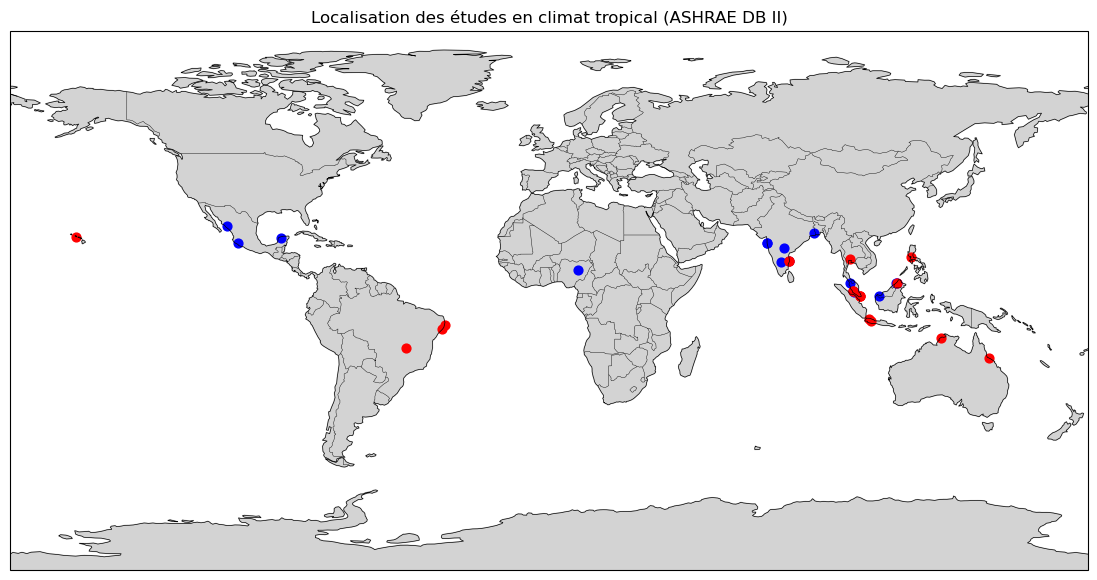

In [79]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_global()
ax.add_feature(cfeature.LAND, color="lightgrey")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

ax.scatter(coordonnees_logements["lon"], coordonnees_logements["lat"], color="blue", s=40, transform=ccrs.PlateCarree())
ax.scatter(coordonnees_bureaux["lon"], coordonnees_bureaux["lat"], color="red", s=40, transform=ccrs.PlateCarree())

plt.title("Localisation des études en climat tropical (ASHRAE DB II)")
plt.show()

In [92]:
print(etudes_tropicales.groupby("building_type")["code_etude"].value_counts())
print(etudes_tropicales.groupby("building_type")["code_etude"].nunique())   # études par type
print(etudes_tropicales["building_type"].value_counts())                    # votes par type

building_type        code_etude                                              
classroom            _003_BuildingID591_592_contributorChristhina_Candido        2074
                     _018_BuildingID543_546_contributorHarimi_Djamila             171
multifamily housing  _008_BuildingID296_462_contributorRajan_Rawal               1070
                     _009_BuildingID705_711_contributorRamona_Romero             1055
                     _011_BuildingID606_614_contributorHarimi_Djamila             863
                     _013_BuildingID166_167_contributorJeetika_Malik              705
                     _015_BuildingID558_559_contributorMichael_Adebamowo          468
office               _001_BuildingID154_165_contributorAlison_Kwok               3544
                     _002_BuildingID653_662_contributorIndraganti_Madhavi        2907
                     _004_BuildingID682_701_contributorSanyogita_Manu            2029
                     _005_BuildingID728_739_contributorSiti_Ai

In [89]:
print("Nombre de batiments :", len(coordonnees_logements))                          
print("Nombre d'études :", coordonnees_logements["code_etude"].nunique())       
print("Nombre de villes :", coordonnees_logements["city"].nunique()) 
print("Nombre de pays :", coordonnees_logements["country"].nunique())     
print("Nombre de batiments par pays :", coordonnees_logements["country"].value_counts())     

Nombre de batiments : 17
Nombre d'études : 5
Nombre de villes : 15
Nombre de pays : 4
Nombre de batiments par pays : country
malaysia    7
india       6
mexico      3
nigeria     1
Name: count, dtype: int64


In [87]:
print("Nombre de batiments :", len(coordonnees_bureaux))                          
print("Nombre d'études :", coordonnees_bureaux["code_etude"].nunique())       
print("Nombre de villes :", coordonnees_bureaux["city"].nunique()) 
print("Nombre de pays :", coordonnees_bureaux["country"].nunique())     
print("Nombre de batiments par pays :", coordonnees_bureaux["country"].value_counts())     

Nombre de batiments : 19
Nombre d'études : 14
Nombre de villes : 16
Nombre de pays : 9
Nombre de batiments par pays : country
india          3
brazil         3
malaysia       3
singapore      3
indonesia      2
australia      2
usa            1
thailand       1
philippines    1
Name: count, dtype: int64
